## **load a CSV file**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


# **Display dataset**

In [ ]:
import pandas as pd
df = pd.read_csv("Housing.csv")

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


# **Convert categorical (yes/no) → (1/0)**

In [ ]:
cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in cols:
    df[col] = df[col].map({'yes':1, 'no':0})

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  
3        furnished  
4        furnished  


# **3D Scatter Plot (area, bedrooms, price)**

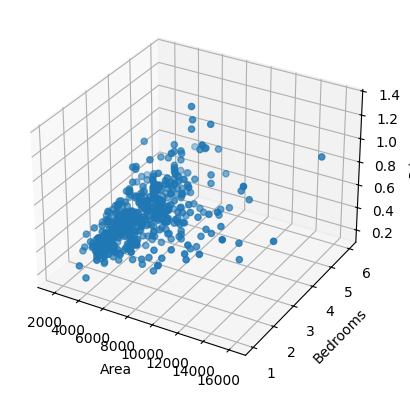

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df.columns = df.columns.str.strip()


df['area'] = pd.to_numeric(df['area'], errors='coerce')
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['area'], df['bedrooms'], df['price'])

ax.set_xlabel('Area')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price')

plt.show()

# **One Hot Encoding (furnishingstatus)**

In [ ]:
df = pd.get_dummies(df, columns=['furnishingstatus'])

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_furnished  furnishingstatus_semi-furnished  \
0                        True                            False   
1                        T

# Train-Test **Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply Linear **Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Predict the **model**

In [ ]:
y_pred = model.predict(X_test)

print("Predictions:\n", y_pred[:5])

Predictions:
 [5164653.90033967 7224722.29802167 3109863.24240338 4612075.32722559
 3294646.25725956]


# **Performance Metrics (MSE, R², RMSE, MAE)**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("MSE :", mse)
print("R2 Score :", r2)
print("RMSE :", rmse)
print("MAE :", mae)

MSE : 1754318687330.6638
R2 Score : 0.6529242642153184
RMSE : 1324506.9600914386
MAE : 970043.4039201641
